# Tutoriel 3

# La structure d'un code : la seiche du Léman

Jusqu'ici, vous complétiez des bouts de code. Ici, vous recevez un **code complet qui fonctionne** : vous allez le lire, le faire tourner, et **jouer avec ses paramètres**. Tous les codes du cours auront cette même structure.

## 1. Le phénomène : le lac qui oscille

Quand une tempête souffle dans l'axe du Léman, le vent pousse l'eau vers Villeneuve et le niveau y monte de quelques centimètres. Le vent tombé, l'eau redescend, dépasse l'équilibre, remonte côté Genève... et le lac oscille lentement, comme l'eau d'une baignoire qu'on aurait inclinée puis relâchée. Ce phénomène s'appelle une **seiche** : sur le Léman, sa période mesurée est d'environ **73 minutes**.

## 2. Le modèle

On décrit le lac le plus simplement possible : une boîte de longueur $L$ et de profondeur $H$, dont l'eau bascule autour du milieu. En notant $\eta(t)$ le **dénivelé à l'extrémité du lac** (en m), on obtient un oscillateur amorti :

$$\frac{d^2 \eta}{dt^2} = \underbrace{- \omega^2 \eta}_{\text{rappel}} \ \underbrace{- \ \gamma \frac{d\eta}{dt}}_{\text{frottement}},
\qquad \omega = \frac{\pi \sqrt{g H}}{L}$$

En posant $v = d\eta/dt$ (la vitesse de montée de l'eau), la discrétisation en temps donne deux mises à jour successives :

```python
v   += dt * ( - omega**2 * eta - gamma * v )   # 1) la vitesse
eta += dt * v                                  # 2) puis la position
```

## 3. La structure d'un code

**Tous** les codes de ce cours sont organisés en cinq blocs, toujours dans le même ordre. Repérez-les dans le code ci-dessous, ils y sont signalés par des commentaires.

| Bloc | Contenu | Exemple ici |
|---|---|---|
| 1. Paramètres **physiques** | ce qui décrit la nature, **avec les unités** | `L`, `H`, `g`, `duree` |
| 2. Paramètres **numériques** | pas de temps, fréquence d'affichage | `dt`, `freq_affich` |
| 3. **Initialisation** | grandeurs calculées une fois, état de départ | `omega`, `eta`, `v` |
| 4. La **figure**, créée **avant** la boucle | `fig, ax = plt.subplots()` | |
| 5. La **boucle temporelle** | le modèle, puis l'affichage | `for it in range(nt):` |

Notez que chaque paramètre porte son unité en commentaire, et qu'**aucune valeur numérique n'est écrite en dur dans la boucle** : c'est ce qui rend possibles les expériences de la section 5.

## 4. Le code complet

Exécutez la cellule et observez le lac osciller.

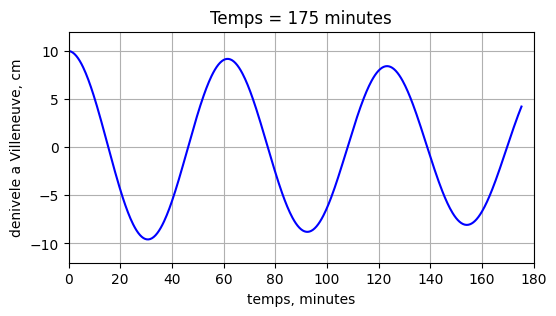

Periode donnee par le modele : 61.7 minutes
Periode mesuree sur le Leman : 73.5 minutes


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# 1) parametres physiques
L     = 72000.0      # longueur du Leman, m
H     = 154.0        # profondeur moyenne, m
g     = 9.81         # pesanteur, m/s2
eta0  = 0.10         # denivele juste apres la tempete, m
tau   = 12*3600.0    # temps caracteristique d'amortissement, s
duree = 3*3600.0     # duree totale simulee, s

# 2) parametres numeriques
dt          = 20.0   # pas de temps, s
freq_affich = 15     # une image toutes les freq_affich iterations

# 3) initialisation
omega = np.pi*np.sqrt(g*H)/L     # pulsation propre du lac, rad/s
gamma = 2.0/tau                  # coefficient d'amortissement, 1/s
nt    = int(duree/dt)
eta, v, temps = eta0, 0.0, 0.0   # denivele (m), vitesse (m/s), temps (s)
eta_sauve, temps_sauve = np.zeros(nt), np.zeros(nt)

# 4) creation de la figure AVANT la boucle
fig, ax = plt.subplots(figsize=(6,3))

# 5) boucle temporelle
for it in range(nt):

    # le modele
    v     += dt*( - omega**2*eta - gamma*v )
    eta   += dt*v
    temps += dt
    eta_sauve[it], temps_sauve[it] = eta, temps

    # affichage
    if it % freq_affich == 0:
        clear_output(wait=True)
        ax.cla()
        ax.plot(temps_sauve[:it+1]/60, eta_sauve[:it+1]*100, c='b')
        ax.set_xlim([0, duree/60]) ; ax.set_ylim([-12, 12]) ; ax.grid(True)
        ax.set_xlabel('temps, minutes') ; ax.set_ylabel('denivele a Villeneuve, cm')
        ax.set_title('Temps = ' + str(round(temps/60)) + ' minutes')
        display(fig) ; plt.pause(0.02)

plt.close()
print("Periode donnee par le modele :", round(2*np.pi/omega/60, 1), "minutes")
print("Periode mesuree sur le Leman : 73.5 minutes")

Le modèle donne le **bon ordre de grandeur** — des dizaines de minutes, et non des secondes ou des jours — mais se trompe de 15 % : nous avons supposé le lac rectangulaire et de profondeur constante, alors qu'il a la forme d'un croissant.

## 5. À expérimenter

1. Passez `H` de 154 à 300 m. L'oscillation est-elle plus rapide ou plus lente ? Est-ce cohérent avec la formule de $\omega$ ?
2. Passez `dt` à 2000 s. Que se passe-t-il ? (Nous verrons au cours 4 pourquoi un pas de temps trop grand fait **exploser** un modèle numérique.)